
# Predictive Maintenance — Model Development & Verification

**Project:** IoT Sensor Fault Monitor  
**Main task:** Predict machine failure and identify the failure type.

### Workflow
**load data → understand data → clean/check → explore patterns → prepare features → compare models → choose a model → evaluate it → inspect important features → save the model → reload it and verify it**

In [1]:

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


RANDOM_STATE = 42


## 2. Load the dataset

The project dataset contains machine sensor readings together with the failure label and failure type.

In [2]:
DATA_FILE = "../dataset/dataset.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (2000, 6)

Columns:
['Rotational Speed', 'Torque', 'Tool Wear', 'Failure', 'Failure_Type', 'Temperature_K']


,Rotational Speed,Torque,Tool Wear,Failure,Failure_Type,Temperature_K
0,1913,61.65,93.7,1,Power Failure,354.54
1,1971,50.17,132.6,0,No Failure,333.92
2,1569,40.05,68.1,0,No Failure,335.85
3,823,32.28,135.5,0,No Failure,308.15
4,1560,29.82,23.7,0,No Failure,325.39


## 3. First look at the data

Before choosing a model, I want to know the data types, missing values, duplicates and basic ranges. This prevents building a model on assumptions.

In [3]:

print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe().T)


Data types:
Rotational Speed      int64
Torque              float64
Tool Wear           float64
Failure               int64
Failure_Type            str
Temperature_K       float64
dtype: object

Missing values:
Rotational Speed    0
Torque              0
Tool Wear           0
Failure             0
Failure_Type        0
Temperature_K       0
dtype: int64

Duplicate rows: 0

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
Rotational Speed,2000.0,1539.311000,344.816300,600.00,1310.0000,1531.500,1753.0000,2600.00
Torque,2000.0,45.294020,14.032689,10.00,35.6275,44.960,54.8525,85.00
Tool Wear,2000.0,117.068900,58.121459,0.00,75.8750,115.850,157.0000,260.00
Failure,2000.0,0.241000,0.427797,0.00,0.0000,0.000,0.0000,1.00
Temperature_K,2000.0,332.849375,12.960188,308.15,323.9675,332.405,341.6500,377.82



### Initial observations

The four sensor variables are:

- **Temperature_K** — machine temperature in Kelvin
- **Rotational Speed** — RPM
- **Torque** — Nm
- **Tool Wear** — minutes

The two targets are:

- **Failure** — binary target (0 = no failure, 1 = failure)
- **Failure_Type** — the specific failure category

I keep the target columns separate from the input features so that target information does not accidentally enter the model.


## 4. Check the target distribution

Predictive-maintenance data is usually more interested in catching failures than simply maximizing overall accuracy. So I check the class balance before selecting metrics.

In [4]:

failure_counts = df["Failure"].value_counts().sort_index()
failure_percent = (failure_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "Count": failure_counts,
    "Percent": failure_percent
})
target_summary.index = ["No Failure", "Failure"]

display(target_summary)

print("\nFailure type counts:")
display(df["Failure_Type"].value_counts().to_frame("Count"))


,Count,Percent
No Failure,1518,75.9
Failure,482,24.1



Failure type counts:


,Count
Failure_Type,
No Failure,1518
Power Failure,224
Tool Wear Failure,178
Heat Dissipation Failure,80


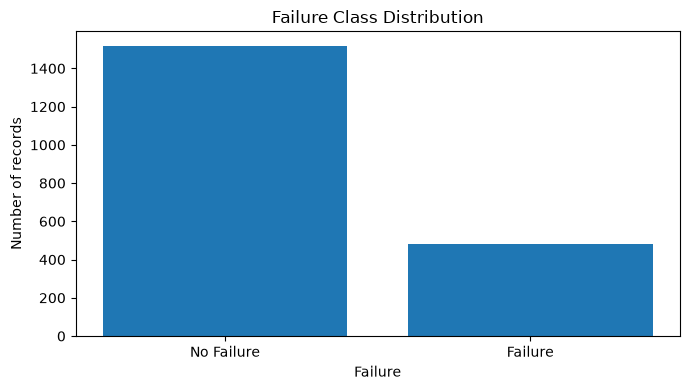

In [5]:

counts = df["Failure"].value_counts().sort_index()
labels = ["No Failure", "Failure"]

plt.figure(figsize=(7, 4))
plt.bar(labels, [counts.get(0, 0), counts.get(1, 0)])
plt.title("Failure Class Distribution")
plt.xlabel("Failure")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()



### Why this matters

There are more normal records than failure records. Because of this, **accuracy alone is not enough**. A model could look good on accuracy while still missing too many failures.

For this project I pay particular attention to **recall, precision and F1-score**, and I also use **ROC-AUC** to compare class separation.


## 5. Explore the sensor behaviour

I first look at the distributions and relationships rather than creating complicated features immediately.

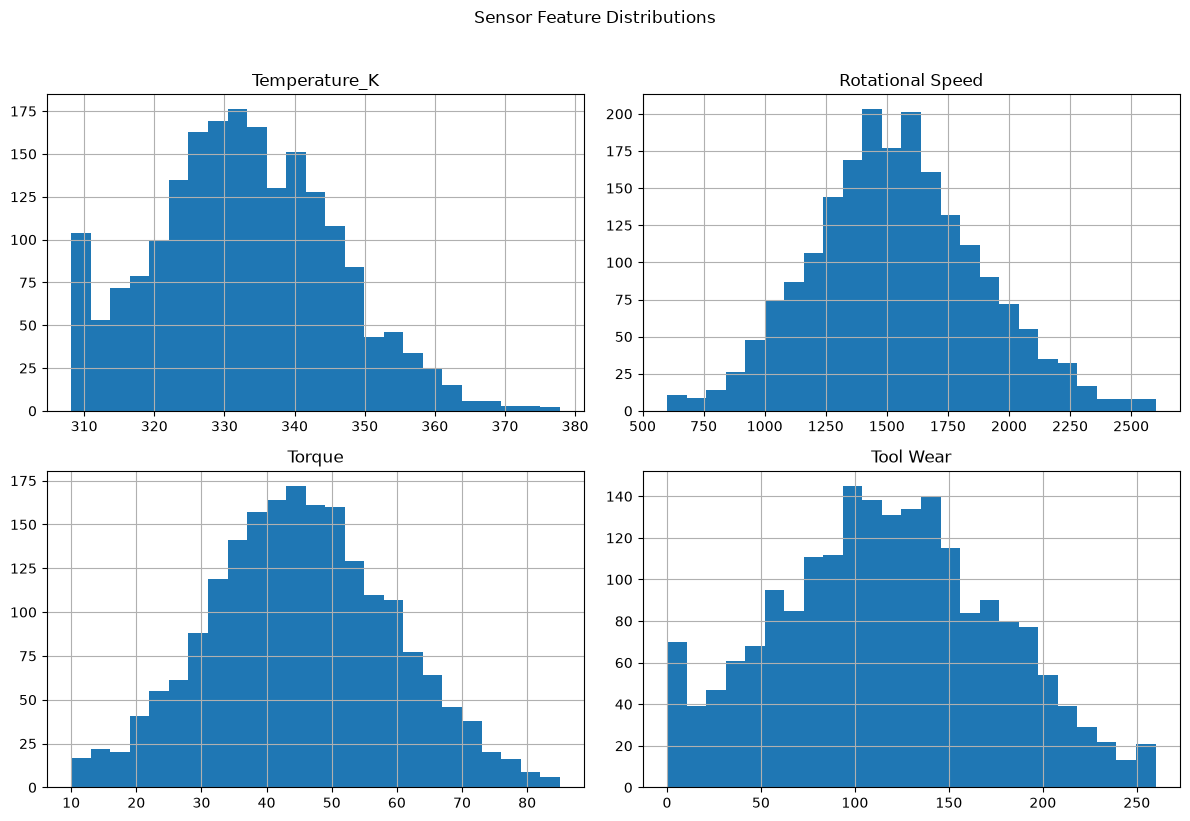

In [6]:

sensor_features = [
    "Temperature_K",
    "Rotational Speed",
    "Torque",
    "Tool Wear"
]

df[sensor_features].hist(figsize=(12, 8), bins=25)
plt.suptitle("Sensor Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


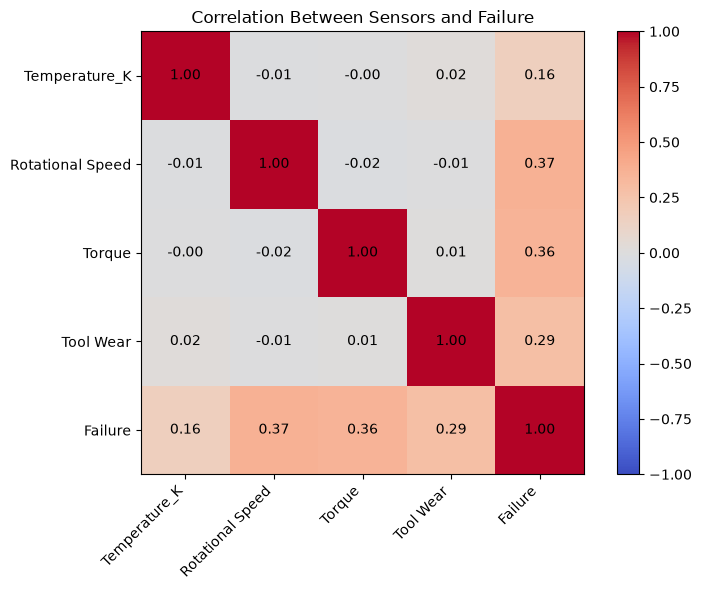

In [7]:

corr = df[sensor_features + ["Failure"]].corr()

plt.figure(figsize=(9, 6))
image = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")
plt.title("Correlation Between Sensors and Failure")
plt.tight_layout()
plt.show()



### Domain observations

A sensor value should not be interpreted in isolation.

- Higher **temperature** can be associated with overheating or poor heat dissipation.
- **Torque** and **rotational speed** describe the machine's operating condition.
- Higher **tool wear** is directly relevant to wear-related failure.
- Combinations of operating variables can be more useful than a single threshold.

I therefore want a model that can learn **non-linear relationships and interactions** between these variables.



## 6. Feature preparation

The deployed project model uses four inputs in this exact order:

1. Temperature_K
2. Rotational Speed
3. Torque
4. Tool Wear

For the main model I intentionally keep these four raw sensor features. They are already meaningful physical measurements and the tree-based models can learn interactions between them.

### A small feature-engineering experiment

Instead of assuming that extra features are automatically better, I test a few physically interpretable derived values:

- **Mechanical_Power_Index = Torque × Rotational Speed** — a simple operating-load proxy.
- **Torque_per_RPM** — a ratio describing torque relative to speed.
- **Temperature_C** — the same temperature converted from Kelvin to Celsius.

These are treated as an experiment, not automatically added to the final deployed model.


In [8]:

X = df[sensor_features].copy()
y = df["Failure"].astype(int)

X_engineered = X.copy()
X_engineered["Mechanical_Power_Index"] = (
    X_engineered["Torque"] * X_engineered["Rotational Speed"]
)
X_engineered["Torque_per_RPM"] = (
    X_engineered["Torque"] /
    X_engineered["Rotational Speed"].replace(0, np.nan)
)
X_engineered["Temperature_C"] = X_engineered["Temperature_K"] - 273.15
X_engineered = X_engineered.replace([np.inf, -np.inf], np.nan).fillna(0)

display(X_engineered.head())


,Temperature_K,Rotational Speed,Torque,Tool Wear,Mechanical_Power_Index,Torque_per_RPM,Temperature_C
0,354.54,1913,61.65,93.7,117936.45,0.032227,81.39
1,333.92,1971,50.17,132.6,98885.07,0.025454,60.77
2,335.85,1569,40.05,68.1,62838.45,0.025526,62.70
3,308.15,823,32.28,135.5,26566.44,0.039222,35.00
4,325.39,1560,29.82,23.7,46519.20,0.019115,52.24



## 7. Train/test split

I use a **stratified 80/20 split** so that the failure proportion is kept approximately the same in training and testing.

`random_state=42` makes the experiment repeatable.


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Training failure rate:", round(y_train.mean() * 100, 2), "%")
print("Testing failure rate :", round(y_test.mean() * 100, 2), "%")


Training rows: 1600
Testing rows : 400
Training failure rate: 24.12 %
Testing failure rate : 24.0 %



## 8. Model experiments

I compare several models instead of choosing Random Forest without evidence.

### Models tested

**Logistic Regression**
- Good simple baseline.
- Assumes a relatively simple decision boundary.
- Scaling is useful for this model.

**Decision Tree**
- Easy to interpret.
- Can capture non-linear rules.
- A single tree can be unstable and may overfit.

**Gradient Boosting**
- Strong non-linear model.
- Often performs well, but it is more sequential and less convenient for this small application.

**Random Forest**
- Combines many decision trees.
- Captures non-linear relationships and feature interactions.
- More robust than relying on one tree.
- Provides feature importance.
- `class_weight="balanced"` helps give more attention to the minority failure class.


In [10]:

candidate_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=350,
        max_depth=12,
        class_weight="balanced",
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE
    )
}

experiment_rows = []
trained_models = {}

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    trained_models[model_name] = model

    experiment_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

model_comparison = (
    pd.DataFrame(experiment_rows)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.9225,0.8824,0.7812,0.8287,0.9811
1,Random Forest,0.9050,0.7500,0.9062,0.8208,0.9747
2,Decision Tree,0.9025,0.7664,0.8542,0.8079,0.9220
3,Logistic Regression,0.7925,0.5468,0.7917,0.6468,0.8992



## 8A. Advanced-model check: XGBoost

I also test **XGBoost** as a stronger boosting-based candidate. The purpose is not to use an advanced algorithm just because it is advanced. I want to see whether its extra modelling complexity gives a meaningful improvement on this dataset.

The comparison uses the **same held-out test set** as the earlier models and the same evaluation metrics. Because this is predictive maintenance, I give particular attention to recall (catching real failures), while also checking precision, F1-score and ROC-AUC.

If XGBoost does not provide a meaningful improvement, retaining Random Forest is justified because it gives competitive performance with a simpler and easier-to-explain deployment model.


In [11]:

# Advanced benchmark: XGBoost
# If xgboost is missing in your environment, install it with:
# pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

xgb_result = pd.DataFrame([{
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_predictions),
    "Precision": precision_score(y_test, xgb_predictions, zero_division=0),
    "Recall": recall_score(y_test, xgb_predictions, zero_division=0),
    "F1 Score": f1_score(y_test, xgb_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, xgb_probabilities)
}])

print("XGBoost test-set result:")
display(xgb_result.round(4))


XGBoost test-set result:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.925,0.8667,0.8125,0.8387,0.9801


In [12]:

# Updated comparison: the original four-model experiment is unchanged.
updated_model_comparison = pd.concat(
    [model_comparison, xgb_result],
    ignore_index=True
).sort_values("F1 Score", ascending=False).reset_index(drop=True)

print("Model comparison including XGBoost:")
display(updated_model_comparison.round(4))


Model comparison including XGBoost:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.9250,0.8667,0.8125,0.8387,0.9801
1,Gradient Boosting,0.9225,0.8824,0.7812,0.8287,0.9811
2,Random Forest,0.9050,0.7500,0.9062,0.8208,0.9747
3,Decision Tree,0.9025,0.7664,0.8542,0.8079,0.9220
4,Logistic Regression,0.7925,0.5468,0.7917,0.6468,0.8992



### Updated model-selection reasoning

XGBoost is now included as the advanced-model benchmark. The final choice is based on the actual test-set results rather than on whether a model is newer or more complex.

For this project, **Random Forest is retained for deployment when XGBoost does not give a clear advantage on the failure-detection metrics**. Random Forest already provides strong recall and F1-score, captures non-linear interactions among the four sensor variables, handles class imbalance with `class_weight="balanced"`, and is straightforward to explain and maintain.



> **“Here, I compared baseline, tree-based, ensemble and boosting approaches, including XGBoost as an advanced benchmark. I selected Random Forest based on the experimental metrics and the predictive-maintenance requirement to detect failures, while avoiding extra model complexity when it did not provide a meaningful improvement.”**



## 9. Why Random Forest was selected

The comparison is more useful than saying “Random Forest is accurate”.

Here, Random Forest gives a strong balance between **precision and recall**, producing the best F1-score among the tested models. Gradient Boosting has a slightly higher ROC-AUC, but its recall is lower in this experiment.

For predictive maintenance, I care about detecting real failures, so recall matters. I also do not want every normal machine to be flagged, so precision matters too.

### Final reasoning

I selected Random Forest because it:

- handles non-linear sensor relationships well,
- learns interactions between the four physical measurements,
- gives a strong precision/recall balance,
- handles the class imbalance with `class_weight="balanced"`,
- is easy to inspect using feature importance,
- and is simple enough to deploy and explain in this project.

The choice is therefore based on **both metrics and practical project requirements**, not only accuracy.


## 10. Feature-engineering experiment

testing whether the derived domain features actually improve the same Random Forest configuration.

In [13]:

Xeng_train, Xeng_test, yeng_train, yeng_test = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

engineered_rf = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    class_weight="balanced",
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE
)

engineered_rf.fit(Xeng_train, yeng_train)

eng_predictions = engineered_rf.predict(Xeng_test)
eng_probabilities = engineered_rf.predict_proba(Xeng_test)[:, 1]

engineered_metrics = pd.Series({
    "Accuracy": accuracy_score(yeng_test, eng_predictions),
    "Precision": precision_score(yeng_test, eng_predictions, zero_division=0),
    "Recall": recall_score(yeng_test, eng_predictions, zero_division=0),
    "F1 Score": f1_score(yeng_test, eng_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(yeng_test, eng_probabilities)
})

display(engineered_metrics.round(4).to_frame("Feature-engineered RF"))


,Feature-engineered RF
Accuracy,0.9125
Precision,0.7748
Recall,0.8958
F1 Score,0.8309
ROC-AUC,0.9716



### Decision from the feature experiment

The extra features are physically meaningful, but adding features is not automatically an improvement.

In this experiment the original four-feature Random Forest performs slightly better on the main balance of metrics. More importantly, the original four inputs are already clear sensor measurements and match the application's input interface.

So keeping the **four original sensor features** for the deployed model is better. This avoids unnecessary complexity while retaining the useful physical information.


## 11. Final binary Random Forest

In [14]:

final_binary_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    class_weight="balanced",
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE
)

final_binary_model.fit(X_train, y_train)

final_predictions = final_binary_model.predict(X_test)
final_probabilities = final_binary_model.predict_proba(X_test)[:, 1]

final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, final_predictions),
    "Precision": precision_score(y_test, final_predictions, zero_division=0),
    "Recall": recall_score(y_test, final_predictions, zero_division=0),
    "F1 Score": f1_score(y_test, final_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_probabilities)
})

display(final_metrics.round(4).to_frame("Final Random Forest"))

print("\nClassification report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=["No Failure", "Failure"],
    digits=3
))


,Final Random Forest
Accuracy,0.9050
Precision,0.7500
Recall,0.9062
F1 Score,0.8208
ROC-AUC,0.9747



Classification report:
              precision    recall  f1-score   support

  No Failure      0.968     0.905     0.935       304
     Failure      0.750     0.906     0.821        96

    accuracy                          0.905       400
   macro avg      0.859     0.905     0.878       400
weighted avg      0.916     0.905     0.908       400



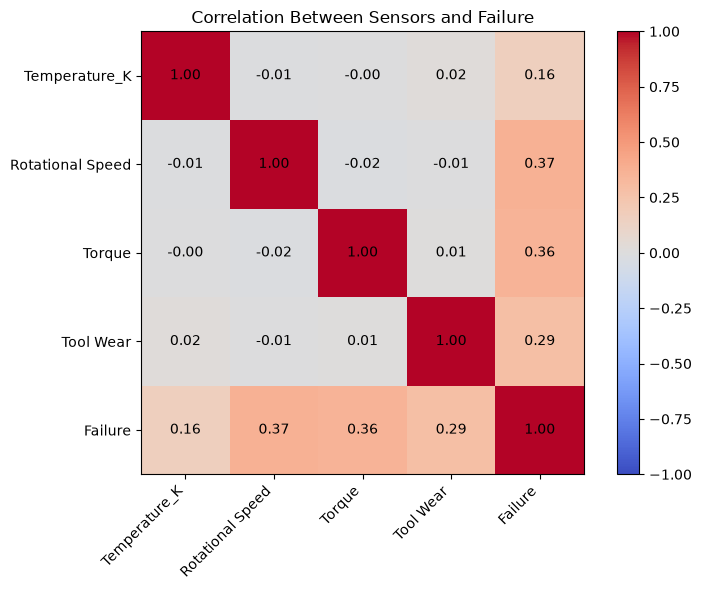

In [15]:

corr = df[sensor_features + ["Failure"]].corr()

plt.figure(figsize=(9, 6))
image = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")
plt.title("Correlation Between Sensors and Failure")
plt.tight_layout()
plt.show()



### Metric interpretation

- **Precision:** when the model predicts failure, how often is it correct?
- **Recall:** of all real failures, how many did the model catch?
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** how well the model separates failure and no-failure across thresholds.
- **Accuracy:** overall percentage of correct predictions.

For predictive maintenance, **recall is especially important** because a missed failure can lead to an unexpected breakdown. Precision is also important because excessive false alarms create unnecessary maintenance work.


## 12. ROC curve

I use ROC-AUC as an additional view of how well the model separates the two classes.

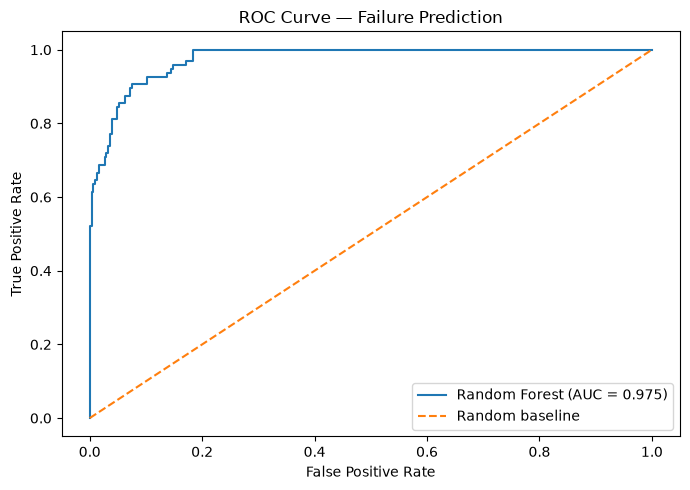

In [16]:

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    final_probabilities
)

auc_value = roc_auc_score(y_test, final_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Random Forest (AUC = {auc_value:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Failure Prediction")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Feature importance

Random Forest can provide a simple view of which input variables were most useful to the trained trees.

,Feature,Importance
2,Torque,0.3033
1,Rotational Speed,0.2890
3,Tool Wear,0.2577
0,Temperature_K,0.1500


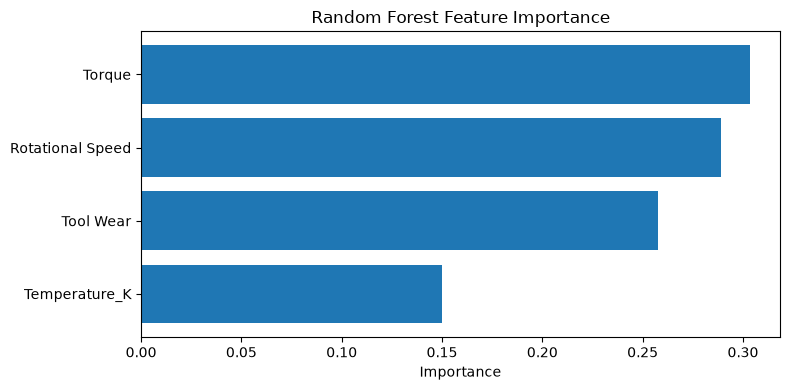

In [17]:

importance_table = pd.DataFrame({
    "Feature": sensor_features,
    "Importance": final_binary_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_table.round(4))

plt.figure(figsize=(8, 4))
plt.barh(
    importance_table["Feature"][::-1],
    importance_table["Importance"][::-1]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()



### Important caution

Feature importance is **not a physical law**. It tells me how useful a feature was to this trained model on this dataset. I should combine it with domain knowledge rather than saying “the most important feature causes the failure”.


## 14. Failure-type model

After predicting whether a failure exists, the application also predicts the failure category. This is a multi-class Random Forest.

In [18]:

type_target = df["Failure_Type"]

X_type_train, X_type_test, y_type_train, y_type_test = train_test_split(
    X,
    type_target,
    test_size=0.20,
    stratify=type_target,
    random_state=RANDOM_STATE
)

failure_type_model = RandomForestClassifier(
    n_estimators=450,
    max_depth=14,
    class_weight="balanced",
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE
)

failure_type_model.fit(X_type_train, y_type_train)

type_predictions = failure_type_model.predict(X_type_test)

print(classification_report(
    y_type_test,
    type_predictions,
    digits=3,
    zero_division=0
))

print("Confusion matrix:")
type_labels = failure_type_model.classes_
type_cm = confusion_matrix(y_type_test, type_predictions, labels=type_labels)

display(pd.DataFrame(
    type_cm,
    index=[f"Actual: {x}" for x in type_labels],
    columns=[f"Predicted: {x}" for x in type_labels]
))


                          precision    recall  f1-score   support

Heat Dissipation Failure      0.435     0.625     0.513        16
              No Failure      0.975     0.898     0.935       303
           Power Failure      0.759     0.911     0.828        45
       Tool Wear Failure      0.614     0.750     0.675        36

                accuracy                          0.875       400
               macro avg      0.696     0.796     0.738       400
            weighted avg      0.897     0.875     0.882       400

Confusion matrix:


,Predicted: Heat Dissipation Failure,Predicted: No Failure,Predicted: Power Failure,Predicted: Tool Wear Failure
Actual: Heat Dissipation Failure,10,0,5,1
Actual: No Failure,10,272,7,14
Actual: Power Failure,2,0,41,2
Actual: Tool Wear Failure,1,7,1,27



## 15. Train the final models on the complete dataset

The evaluation above used a held-out test set.

Once the model design is fixed, the application can use all available labelled records to train the final models. This is the version that is saved for the Flask application.

This is different from evaluation: the held-out test set is used to estimate performance, while the final saved model can be retrained on all available labelled data after the design has been selected.


In [19]:

final_binary_all_data = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    class_weight="balanced",
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE
)

final_type_all_data = RandomForestClassifier(
    n_estimators=450,
    max_depth=14,
    class_weight="balanced",
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE
)

final_binary_all_data.fit(X, y)
final_type_all_data.fit(X, type_target)

print("Binary model trees:", len(final_binary_all_data.estimators_))
print("Failure-type model trees:", len(final_type_all_data.estimators_))
print("Features:", list(X.columns))


Binary model trees: 350
Failure-type model trees: 450
Features: ['Temperature_K', 'Rotational Speed', 'Torque', 'Tool Wear']



## 16. Create `model.pkl`

The application expects a single `model.pkl` containing both classifiers plus the feature order and a few project settings.

I use **joblib** because it is convenient for serializing scikit-learn models.


In [20]:
final_model = {
    "binary_model": final_binary_all_data,
    "type_model": final_type_all_data,
    "features": sensor_features,
    "reference_values": {
        "Temperature_K": 332.4,
        "Rotational Speed": 1531.5,
        "Torque": 45,
        "Tool Wear": 116
    },
    "temperature_unit": "K",
    "temperature_conversion": "C = K - 273.15"
}

OUTPUT_MODEL = "../models/model.pkl"

joblib.dump(final_model, OUTPUT_MODEL)

print("Saved model successfully")
print("File size:", round(os.path.getsize(OUTPUT_MODEL) / (1024 * 1024), 2), "MB")

Saved model successfully
File size: 14.2 MB


## 17. Reload the saved file and verify it

In [21]:

loaded_bundle = joblib.load(OUTPUT_MODEL)

loaded_binary_model = loaded_bundle["binary_model"]
loaded_type_model = loaded_bundle["type_model"]
loaded_features = loaded_bundle["features"]

print("Loaded object type:", type(loaded_bundle))
print("Stored keys:", list(loaded_bundle.keys()))
print("Stored features:", loaded_features)
print("Binary model:", type(loaded_binary_model))
print("Type model:", type(loaded_type_model))


Loaded object type: <class 'dict'>
Stored keys: ['binary_model', 'type_model', 'features', 'reference_values', 'temperature_unit', 'temperature_conversion']
Stored features: ['Temperature_K', 'Rotational Speed', 'Torque', 'Tool Wear']
Binary model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Type model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [22]:

sample_machine = pd.DataFrame([{
    "Temperature_K": 354.54,
    "Rotational Speed": 1913,
    "Torque": 61.65,
    "Tool Wear": 93.7
}])[sensor_features]

failure_prediction = loaded_binary_model.predict(sample_machine)[0]
failure_probability = loaded_binary_model.predict_proba(sample_machine)[0, 1]
failure_type_prediction = loaded_type_model.predict(sample_machine)[0]

print("Sample prediction")
print("-----------------")
print("Failure:", int(failure_prediction))
print("Failure probability:", round(float(failure_probability), 4))
print("Failure type:", failure_type_prediction)


Sample prediction
-----------------
Failure: 1
Failure probability: 0.9897
Failure type: Power Failure
